### Libraries to install.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

### Example dataset

In [5]:

studied_hours = np.arange(1, 11)

test_result = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])


### Training the model

In [6]:
model = LogisticRegression()

X = studied_hours.reshape(-1, 1)

model.fit(X, test_result)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Getting predictions for new data

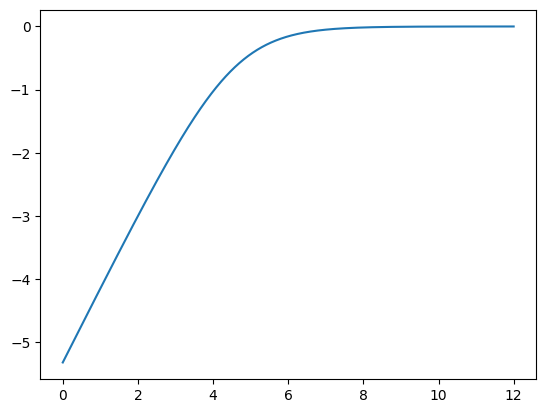

In [7]:
new_hours = np.linspace(0,12,1000).reshape(-1, 1)

probability = model.predict_log_proba(new_hours)[:,1]

plt.plot(new_hours, probability)
plt.show()


### Visualizing the data

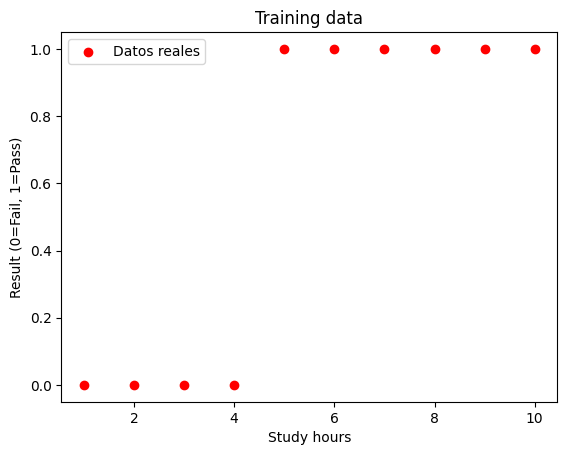

In [8]:
plt.scatter(studied_hours, test_result, color='red', label='Datos reales')
plt.xlabel('Study hours')
plt.ylabel('Result (0=Fail, 1=Pass)')
plt.title('Training data')
plt.legend()
plt.show()

### Visualization with logistic curve

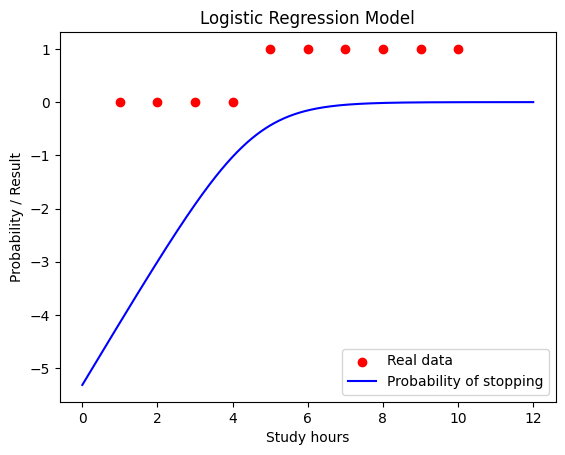

In [9]:
plt.scatter(studied_hours, test_result, color='red', label='Real data')
plt.plot(new_hours , probability, color='blue', label='Probability of stopping')
plt.xlabel('Study hours')
plt.ylabel('Probability / Result')
plt.title('Logistic Regression Model')
plt.legend()
plt.show()

### Printing coefficients

In [10]:
print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient: {model.coef_[0][0]}")

Intercept: -5.311674343465787
Coefficient: 1.181949430069053


### Table with probabilities

In [13]:
original_probabilities = model.predict_proba(X)[:, 1]
df = pd.DataFrame({
    "original_probabilities": original_probabilities,
    "predicted_classes": model.predict(X),
})
print(df) 
df.to_csv("./logistic_regression/logistic_regression2.csv", index=False)

   original_probabilities  predicted_classes
0                0.015833                  0
1                0.049842                  0
2                0.146062                  0
3                0.358041                  0
4                0.645215                  1
5                0.855700                  1
6                0.950826                  1
7                0.984387                  1
8                0.995159                  1
9                0.998510                  1


OSError: Cannot save file into a non-existent directory: 'logistic_regression'

## Exercise with Real Variability Data

In [ ]:
var_hours = np.array ([1,2,3,4,5,6,7,8,9,10,1,8,5,7,9])

var_result = np.array ([0,0,0,0,1,1,1,1,1,1,0,0,1,1,0])

model = LogisticRegression()
model.fit(var_hours.reshape(-1,1), var_result)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Training model with new data

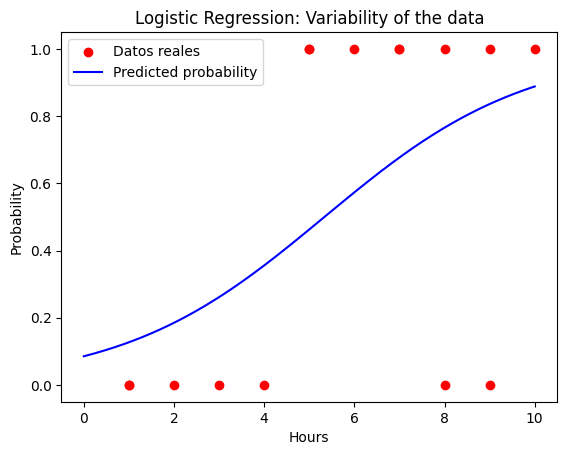

In [ ]:
var_model = LogisticRegression()

X_var = var_hours.reshape(-1, 1)

var_model.fit(X_var, var_result)

var_new_hours = (np.linspace(0, 10, 1000)).reshape(-1, 1)

var_possibilities = var_model.predict_proba(var_new_hours)[:, 1]

plt.scatter(var_hours, var_result, color='red', label='Datos reales')
plt.plot(var_new_hours, var_possibilities, color='blue', label='Predicted probability')
plt.title('Logistic Regression: Variability of the data')
plt.xlabel('Hours')
plt.ylabel('Probability')
plt.legend()
plt.show()


#### Comparing and ordering tables

In [ ]:
print(f"New intercept: {var_model.intercept_[0]}")
print(f"New coefficient: {var_model.coef_[0][0]}")

New intercept: -2.3727748971403235
New coefficient: 0.44461021568267756


## Probabilities ordered table

In [ ]:
df_var = pd.DataFrame({
    "Studies hours": var_hours,
    "Probabilities of approval": var_model.predict_proba(X_var)[:, 1]

})

print("Table of probabilities by order")
print(df_var.sort_values(by="Probabilities of approval", ascending=False).reset_index(drop=True).to_string(index=False))

Table of probabilities by order
 Studies hours  Probabilities of approval
            10                   0.888284
             9                   0.835994
             9                   0.835994
             8                   0.765685
             8                   0.765685
             7                   0.676886
             7                   0.676886
             6                   0.573192
             5                   0.462639
             5                   0.462639
             4                   0.355641
             3                   0.261354
             2                   0.184891
             1                   0.126954
             1                   0.126954
